# Function 2 Analysis - Week 13

**Function description:** Imagine a black box, or a mystery ML model, that takes two numbers as input and returns a log-likelihood score. Your goal is to maximise that score, but each output is noisy, and depending on where you start, you might get stuck in a local optimum. To tackle this, you use Bayesian optimisation, which selects the next inputs based on what it has learned so far. It balances exploration with exploitation, making it well suited to noisy outputs and complex functions with many local peaks.

## Week 12 evaluated point and assessment
- **Evaluated point:** `(0.698551, 0.968116)` -> **y = 0.512152**
- **Assessment:** **Poor point** relative to the best historical region.
- **Why:** The result is well below the best score and below the strongest recent candidates, suggesting this move likely drifted away from the most productive local ridge.

## High-level recommendation for final week
Use a **final exploitative step** near the historically best neighborhood (high-performing incumbent zone), with strict anti-duplicate constraints and minimal exploratory drift.


In [4]:
from pathlib import Path
import numpy as np, pandas as pd, seaborn as sns, matplotlib.pyplot as plt
sns.set_theme(style="ticks", context="notebook")
path = Path("../../initial_data/function_2")
X = np.load(path / "initial_inputs.npy")
y = np.load(path / "initial_outputs.npy")

# Week 1–8 new points
X_new_point_week_1 = np.array([[0.850000, 0.250000]])
y_new_point_week_1 = np.array([0.4588155729748088])
X_new_point_week_2 = np.array([[0.535400, 0.505100]])
y_new_point_week_2 = np.array([0.4687657102198476])
X_new_point_week_3 = np.array([[0.700000, 0.525000]])
y_new_point_week_3 = np.array([0.5521137017632074])
X_new_point_week_4 = np.array([[0.272472, 0.939888]])
y_new_point_week_4 = np.array([-0.04847445058575585])
X_new_point_week_5 = np.array([[0.680788, 1.000000]])
y_new_point_week_5 = np.array([0.4711629392317611])
X_new_point_week_6 = np.array([[0.734569, 0.990000]])
y_new_point_week_6 = np.array([0.3100296239758809])
X_new_point_week_7 = np.array([[0.680788, 1.000000]])
y_new_point_week_7 = np.array([0.67032012103923])
X_new_point_week_8 = np.array([[0.690000, 0.900000]])
y_new_point_week_8 = np.array([0.6255292381456191])
X_new_point_week_9 = np.array([[0.692542, 0.990644]])
y_new_point_week_9 = np.array([0.745718066464249])
X_new_point_week_10 = np.array([[0.697966, 0.991186]])
y_new_point_week_10 = np.array([0.6416389773332486])
X_new_point_week_11 = np.array([[0.703898, 0.982373]])
y_new_point_week_11 = np.array([0.6361756142699612])
X_new_point_week_12 = np.array([[0.698551, 0.968116]])
y_new_point_week_12 = np.array([0.5121524681912992])

X = np.vstack([
    X,
    X_new_point_week_1,
    X_new_point_week_2,
    X_new_point_week_3,
    X_new_point_week_4,
    X_new_point_week_5,
    X_new_point_week_6,
    X_new_point_week_7,
    X_new_point_week_8,
    X_new_point_week_9,
    X_new_point_week_10,
    X_new_point_week_11,
    X_new_point_week_12,
])
y = np.concatenate([
    y,
    y_new_point_week_1,
    y_new_point_week_2,
    y_new_point_week_3,
    y_new_point_week_4,
    y_new_point_week_5,
    y_new_point_week_6,
    y_new_point_week_7,
    y_new_point_week_8,
    y_new_point_week_9,
    y_new_point_week_10,
    y_new_point_week_11,
    y_new_point_week_12,
])

df = pd.DataFrame(X, columns=["x1", "x2"]); df["y"] = y
display(df)
print("df sorted by y")
df_sorted = df.sort_values("y", ascending=False).reset_index(drop=True)
display(df_sorted)


,x1,x2,y
0,0.665800,0.123969,0.538996
1,0.877791,0.778628,0.420586
2,0.142699,0.349005,-0.065624
3,0.845275,0.711120,0.293993
4,0.454647,0.290455,0.214965
5,0.577713,0.771973,0.023106
6,0.438166,0.685018,0.244619
7,0.341750,0.028698,0.038749
8,0.338648,0.213867,-0.013858
9,0.702637,0.926564,0.611205


df sorted by y


,x1,x2,y
0,0.692542,0.990644,0.745718
1,0.680788,1.000000,0.670320
2,0.697966,0.991186,0.641639
3,0.703898,0.982373,0.636176
4,0.690000,0.900000,0.625529
5,0.702637,0.926564,0.611205
6,0.700000,0.525000,0.552114
7,0.665800,0.123969,0.538996
8,0.698551,0.968116,0.512152
9,0.680788,1.000000,0.471163


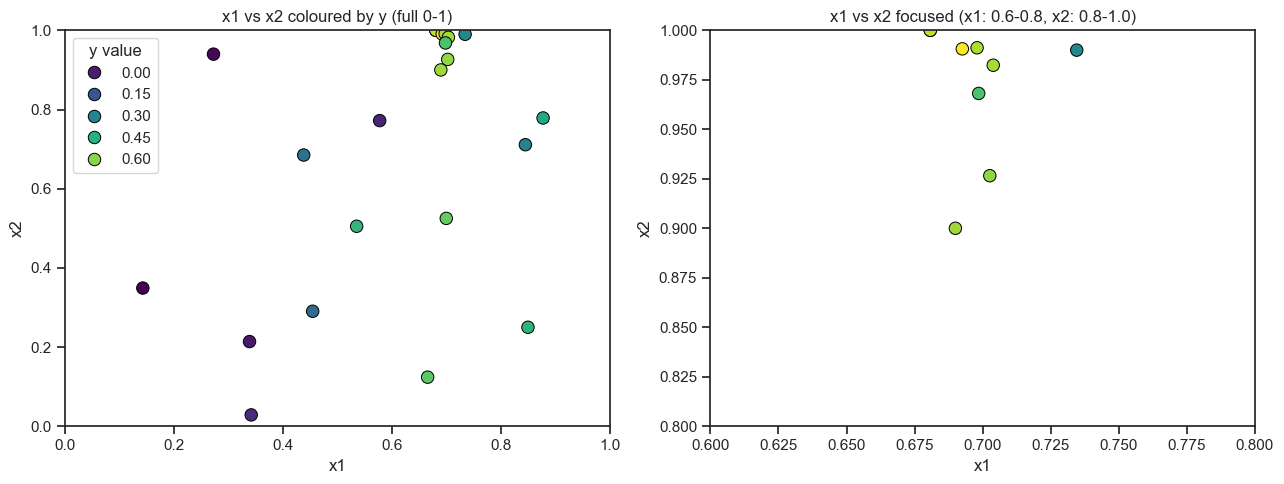

In [5]:
fig, (ax_full, ax_zoom) = plt.subplots(1, 2, figsize=(13, 5))

# Full map (existing 0-1 view)
sns.scatterplot(
    data=df,
    x="x1",
    y="x2",
    hue="y",
    palette="viridis",
    s=80,
    edgecolor="black",
    ax=ax_full,
)
ax_full.set_xlim(0, 1)
ax_full.set_ylim(0, 1)
ax_full.set_title("x1 vs x2 coloured by y (full 0-1)")
ax_full.set_xlabel("x1")
ax_full.set_ylabel("x2")

# Overlay feature-BO recommendation on both plots (if computed below)
try:
    ax_full.scatter(
        X_recommend_updated[0, 0],
        X_recommend_updated[0, 1],
        c="red",
        s=200,
        marker="*",
        edgecolor="white",
        linewidths=2,
        label="Feature BO rec",
    )
except NameError:
    pass

# Focused map (requested narrow square)
sns.scatterplot(
    data=df,
    x="x1",
    y="x2",
    hue="y",
    palette="viridis",
    s=80,
    edgecolor="black",
    ax=ax_zoom,
    legend=False,
)
ax_zoom.set_xlim(0.6, 0.8)
ax_zoom.set_ylim(0.8, 1.0)
ax_zoom.set_title("x1 vs x2 focused (x1: 0.6-0.8, x2: 0.8-1.0)")
ax_zoom.set_xlabel("x1")
ax_zoom.set_ylabel("x2")

try:
    ax_zoom.scatter(
        X_recommend_updated[0, 0],
        X_recommend_updated[0, 1],
        c="red",
        s=200,
        marker="*",
        edgecolor="white",
        linewidths=2,
        label="Feature BO rec",
    )
except NameError:
    pass

ax_full.legend(title="y value", loc="best")
plt.tight_layout()
plt.show()


In [6]:
# Feature-engineered BO (final call): strongly exploitative PI near incumbent
from scipy.stats import norm
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel, Matern, WhiteKernel

df_feat = df.copy()
df_feat["dist_to_x1_0_7"] = np.abs(df_feat["x1"] - 0.7)

X_train = df_feat[["x1", "x2", "dist_to_x1_0_7"]].values
y_train = df_feat["y"].values

best_row_obs = df_feat.loc[df_feat["y"].idxmax()]
best_y = float(best_row_obs["y"])
best_x1 = float(best_row_obs["x1"])
best_x2 = float(best_row_obs["x2"])

# Fit a GP with moderate noise handling; exploitation comes from PI + local filters
kernel = (
    ConstantKernel(1.0, (1e-3, 20.0))
    * Matern(length_scale=[0.10, 0.10, 0.05], length_scale_bounds=(0.01, 0.4), nu=2.5)
    + WhiteKernel(noise_level=0.03, noise_level_bounds=(1e-4, 0.2))
)
gp_bo = GaussianProcessRegressor(kernel=kernel, normalize_y=True, n_restarts_optimizer=10, random_state=42)
gp_bo.fit(X_train, y_train)

# Very local box around incumbent high region (x1~0.7, x2~1.0)
bo_x1_min, bo_x1_max = max(0.60, best_x1 - 0.04), min(0.80, best_x1 + 0.04)
bo_x2_min, bo_x2_max = max(0.90, best_x2 - 0.05), 1.00
grid_res = 90

bo_grid_x1 = np.linspace(bo_x1_min, bo_x1_max, grid_res)
bo_grid_x2 = np.linspace(bo_x2_min, bo_x2_max, grid_res)
bo_mesh_2d = np.array(np.meshgrid(bo_grid_x1, bo_grid_x2)).reshape(2, -1).T
bo_dist = np.abs(bo_mesh_2d[:, 0] - 0.7)
bo_mesh_3d = np.column_stack([bo_mesh_2d, bo_dist])

mu_bo, sigma_bo = gp_bo.predict(bo_mesh_3d, return_std=True)
sigma_bo = np.maximum(sigma_bo, 1e-9)

# Probability of Improvement (very exploitative)
xi = 0.0005
gamma = (mu_bo - best_y - xi) / sigma_bo
pi_bo = norm.cdf(gamma)

candidate_df = pd.DataFrame({
    "x1": bo_mesh_2d[:, 0],
    "x2": bo_mesh_2d[:, 1],
    "dist_to_x1_0_7": bo_dist,
    "mu": mu_bo,
    "sigma": sigma_bo,
    "pi": pi_bo,
})

# Tight focus around incumbent to enforce final-call exploitation
candidate_df["dist_best"] = np.sqrt((candidate_df["x1"] - best_x1) ** 2 + (candidate_df["x2"] - best_x2) ** 2)
candidate_df = candidate_df[(candidate_df["dist_best"] >= 0.004) & (candidate_df["dist_best"] <= 0.05)].copy()

# Anti-duplicate guardrail
obs_xy = df_feat[["x1", "x2"]].values
cand_xy = candidate_df[["x1", "x2"]].values
if len(cand_xy) > 0:
    min_dist_obs = np.sqrt(((cand_xy[:, None, :] - obs_xy[None, :, :]) ** 2).sum(axis=2)).min(axis=1)
    candidate_df = candidate_df[min_dist_obs >= 0.004].copy()

# Fallback if filters become too strict
if candidate_df.empty:
    candidate_df = pd.DataFrame({
        "x1": bo_mesh_2d[:, 0],
        "x2": bo_mesh_2d[:, 1],
        "dist_to_x1_0_7": bo_dist,
        "mu": mu_bo,
        "sigma": sigma_bo,
        "pi": pi_bo,
    })
    candidate_df["dist_best"] = np.sqrt((candidate_df["x1"] - best_x1) ** 2 + (candidate_df["x2"] - best_x2) ** 2)
    candidate_df = candidate_df[candidate_df["dist_best"] <= 0.07].copy()

# Pick max PI; tie-break with higher mean prediction
best_row = candidate_df.sort_values(["pi", "mu"], ascending=[False, False]).iloc[0]
bo_next_x1, bo_next_x2 = float(best_row["x1"]), float(best_row["x2"])

# Used by plotting cells
X_recommend_updated = np.array([[bo_next_x1, bo_next_x2]])

print(f"Current best observed y: {best_y:.6f} at ({best_x1:.6f}, {best_x2:.6f})")
print(f"PI RECOMMENDED POINT: ({bo_next_x1:.6f}, {bo_next_x2:.6f})")
print(f"Predicted mean: {best_row['mu']:.6f} | PI: {best_row['pi']:.6f}")
print(f"Distance to incumbent: {best_row['dist_best']:.6f}")
print(f"Distance feature |x1-0.7| at recommendation: {abs(bo_next_x1 - 0.7):.6f}")
print(f"Format for submission: {bo_next_x1:.6f}-{bo_next_x2:.6f}")


Current best observed y: 0.745718 at (0.692542, 0.990644)
PI RECOMMENDED POINT: (0.691194, 1.000000)
Predicted mean: 0.643295 | PI: 0.127346
Distance to incumbent: 0.009453
Distance feature |x1-0.7| at recommendation: 0.008806
Format for submission: 0.691194-1.000000


d:\OneDrive\Documents\cursor\imperial_college_capstone\.venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified upper bound 0.4. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
d:\OneDrive\Documents\cursor\imperial_college_capstone\.venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__k2__length_scale is close to the specified upper bound 0.4. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


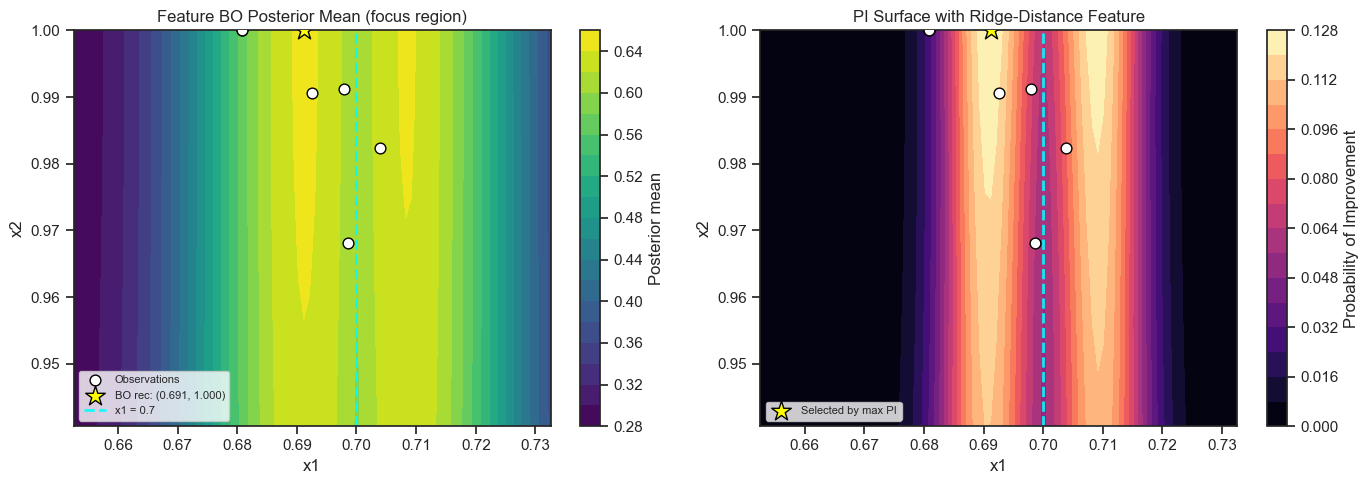


PI-BASED BO RECOMMENDED POINT: (0.691194, 1.000000)
Format for submission: 0.691194-1.000000


In [7]:
# Visualize feature-engineered BO results
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

mu_grid = mu_bo.reshape(grid_res, grid_res)
pi_grid = pi_bo.reshape(grid_res, grid_res)

# Left: posterior mean in focused square
contour1 = ax1.contourf(bo_grid_x1, bo_grid_x2, mu_grid, levels=20, cmap="viridis")
plt.colorbar(contour1, ax=ax1, label="Posterior mean")

# Observations and recommendation
ax1.scatter(df["x1"], df["x2"], c="white", s=60, edgecolor="black", zorder=5, label="Observations")
ax1.scatter(bo_next_x1, bo_next_x2, c="yellow", s=220, marker="*", edgecolor="black", zorder=7,
            label=f"BO rec: ({bo_next_x1:.3f}, {bo_next_x2:.3f})")
ax1.axvline(0.7, color="cyan", linestyle="--", linewidth=2, alpha=0.9, label="x1 = 0.7")

ax1.set_xlim(bo_x1_min, bo_x1_max)
ax1.set_ylim(bo_x2_min, bo_x2_max)
ax1.set_xlabel("x1")
ax1.set_ylabel("x2")
ax1.set_title("Feature BO Posterior Mean (focus region)")
ax1.legend(loc="lower left", fontsize=8)

# Right: PI acquisition surface
contour2 = ax2.contourf(bo_grid_x1, bo_grid_x2, pi_grid, levels=20, cmap="magma")
plt.colorbar(contour2, ax=ax2, label="Probability of Improvement")

ax2.scatter(df["x1"], df["x2"], c="white", s=60, edgecolor="black", zorder=5)
ax2.scatter(bo_next_x1, bo_next_x2, c="yellow", s=220, marker="*", edgecolor="black", zorder=7,
            label="Selected by max PI")
ax2.axvline(0.7, color="cyan", linestyle="--", linewidth=2, alpha=0.9)

ax2.set_xlim(bo_x1_min, bo_x1_max)
ax2.set_ylim(bo_x2_min, bo_x2_max)
ax2.set_xlabel("x1")
ax2.set_ylabel("x2")
ax2.set_title("PI Surface with Ridge-Distance Feature")
ax2.legend(loc="lower left", fontsize=8)

plt.tight_layout()
plt.show()

print(f"\n{'='*60}")
print(f"PI-BASED BO RECOMMENDED POINT: ({bo_next_x1:.6f}, {bo_next_x2:.6f})")
print(f"Format for submission: {bo_next_x1:.6f}-{bo_next_x2:.6f}")
print(f"{'='*60}")


## Final Method Summary

**Current best:** `0.692542-0.990644` (≈0.7457)

**Last evaluated point:** `0.698551-0.968116` returned ≈0.5122, so it did not improve the incumbent.

**What we learned from the previous approach:**
- The previous setup did not produce a new maximum in the last step.
- The highest values are concentrated very close to the corner pattern `x1 ≈ 0.7`, `x2 ≈ 1.0`.
- When we move away from that corner in any direction, the objective drops quickly.

**Final-week strategy (last call): strongly exploitative PI**
- We keep the engineered feature `|x1 - 0.7|` to encode ridge proximity.
- We restrict candidates to a tight local neighborhood around the incumbent.
- We switch acquisition to **Probability of Improvement (PI)** with very small `xi`, to maximize the chance of beating the current best rather than exploring broad uncertain regions.

**Simple pipeline now used:**
1. Train GP on `(x1, x2, |x1-0.7|)`.
2. Build a local candidate grid near the incumbent (`x1~0.7`, `x2` near `1.0`).
3. Score candidates with PI.
4. Remove near-duplicates and keep a small-but-nonzero move.
5. Select the max-PI candidate for submission.

**Proposed next point (submission format):** use the `Format for submission: ...` value printed by the PI BO cell above.
